# Iteraciones de Modelado para crear Features
(Datos Originales NFL)
En este notebook iremos explorando qué features se pueden crear con el propósito de mejorar el desempeño del modelo.

## Requisitos para extraer datos

In [1]:
#import gspread

#from google.colab import auth
#from google.colab import drive
#from google.auth import default
#from functools import reduce

#auth.authenticate_user()
#drive.mount('/content/gdrive')
#creds, _ = default()
#gc = gspread.authorize(creds)

# path
#%cd /content/gdrive/MyDrive/'NFL Big Data Bowl 2025'/

## Imports

In [2]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
import pickle
import scipy.spatial as ss
import seaborn as sns
import shap
import warnings

from functools import reduce
from PIL import Image
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import scale, LabelEncoder
from xgboost import XGBClassifier

from feature_func import (
    get_path, 
    add_prefix_to_dataframe,
    add_player_info_to_tracking,
    influence_function_actual_pos, 
    get_metrics_distance_between_team_players,
    compute_individual_players_info_for_tracking_df,
    encode_position_tracking_df_w_player_info,
    get_general_and_team_info,
    general_vs_team_distance_metrics_info,
    most_influence_info,
)

from graph_feature import *
from plot_utils import *

Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.


## Configuration

In [3]:
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', 5000)

## Constants

In [4]:
nb_tracks = -1
SECONDS = 0.5
RANDOM_SEED = 42

## Paths


In [5]:
BASE_PATH = os.path.join(os.getcwd(), '../')
DATA_PATH = get_path(BASE_PATH, "data")
ORIGINAL_DATA_PATH = get_path(DATA_PATH, "original")
GAMES_PATH = get_path(ORIGINAL_DATA_PATH, "games.csv")
PLAYERS_PATH = get_path(ORIGINAL_DATA_PATH, "players.csv")
PLAYS_PATH = get_path(ORIGINAL_DATA_PATH, "plays.csv")
#PLAYER_PLAY_PATH = get_path(ORIGINAL_DATA_PATH, "player_play.csv")
TRACKING_PATH = get_path(ORIGINAL_DATA_PATH, "tracking")
POSITION_DICT_PATH = get_path(ORIGINAL_DATA_PATH, "position_dictionary.csv")

## Read Data

In [6]:
games_df = pd.read_csv(GAMES_PATH)
players_df = pd.read_csv(PLAYERS_PATH)
play_df = pd.read_csv(PLAYS_PATH)
position_dictionary_df = pd.read_csv(POSITION_DICT_PATH, index_col=0)
tracking_df = pd.concat([
    pd.read_csv(get_path(TRACKING_PATH, f))for f in os.listdir(TRACKING_PATH)[-1:]
])

In [7]:
test_df = tracking_df[(tracking_df.gameId==2022110600)  & (tracking_df.playId==56)]

## Read models

In [8]:
with open('../models/models2/lb_player_position.pkl', 'rb') as f:
    lb_player_position =  pickle.load(f)

with open('../models/models2/lb_player_position_group.pkl', 'rb') as f:
    lb_player_position_group =  pickle.load(f)

with open('../models/models2/lb_player_position_subgroup.pkl', 'rb') as f:
    lb_player_position_subgroup =  pickle.load(f)

In [9]:
with open('../models/models2/presnap_event_encoder.pkl', 'rb') as f:
    presnap_event_encoder =  pickle.load(f)

In [10]:
with open('../models/models2/pca_model.pkl', 'rb') as f:
    pca_model =  pickle.load(f)

with open('../models/models2/pca_model2.pkl', 'rb') as f:
    pca_model2 =  pickle.load(f)
    
with open('../models/models2/pca_model3.pkl', 'rb') as f:
    pca_model3 =  pickle.load(f)

In [11]:
with open('../models/models2/model.pkl', 'rb') as f:
    model = pickle.load(f)

## Slight data modifications

In [12]:
position_encoders = lb_player_position, lb_player_position_group, lb_player_position_subgroup

In [13]:
def initial_data_modifications():
    tracking_df.loc[tracking_df.event == 'autoevent_ballsnap', 'event'] = 'ball_snap'
    tracking_df.loc[tracking_df.event == 'autoevent_passforward', 'event'] = 'pass_forward'
    tracking_df.loc[tracking_df.event == 'autoevent_passinterrupted', 'event'] = 'pass_outcome_incomplete'
    
    players_df['position_group'] = players_df.position.map(position_dictionary_df.T.to_dict()).apply(lambda x: x['group'])
    players_df['position_subgroup'] = players_df.position.map(position_dictionary_df.T.to_dict()).apply(lambda x: x['subgroup'])

In [14]:
def compute_features(df):
    initial_data_modifications()
    """df is partially a tracking_df"""
    
    after_snap_tracking_df = df[df.frameType == 'AFTER_SNAP']
    before_snap_tracking_df = df[df.frameType != 'AFTER_SNAP']

    cols = ['gameId', 'playId', 'frameId', 'time', 'playDirection', 'event']
    event_occurence = after_snap_tracking_df.drop_duplicates(['gameId', 'playId', 'frameId'])[cols]
    current_event_stuff = event_occurence.set_index(['gameId', 'playId', 'frameId'])[['playDirection']]
    current_event_stuff['playDirection'] = current_event_stuff.playDirection.map({'right': 0, 'left': 1})
    
    reduced_play_df = play_df.merge(current_event_stuff.reset_index(level=-1), on=['gameId', 'playId'], how='right')
    reduced_play_df = reduced_play_df.merge(games_df[['gameId', 'homeTeamAbbr', 'visitorTeamAbbr']], on='gameId', how='left')
    reduced_play_df['team_deffinition'] = reduced_play_df.apply(lambda x: {x.possessionTeam: 1, x.defensiveTeam: -1}, axis=1)
    reduced_play_df['gameClock_time'] = reduced_play_df.gameClock.str.split(':').apply(lambda x: int(x[0])*60 + int(x[1]))
    
    home_posseses = reduced_play_df['homeTeamAbbr'] == reduced_play_df['possessionTeam']
    visit_posseses = reduced_play_df['visitorTeamAbbr'] == reduced_play_df['possessionTeam']
    
    home_deffends = reduced_play_df['homeTeamAbbr'] == reduced_play_df['defensiveTeam']
    visit_deffends = reduced_play_df['visitorTeamAbbr'] == reduced_play_df['defensiveTeam']
    
    reduced_play_df.loc[home_posseses, 'preSnapPossessionScore'] = reduced_play_df[home_posseses].preSnapHomeScore
    reduced_play_df.loc[visit_posseses, 'preSnapPossessionScore'] = reduced_play_df[visit_posseses].preSnapVisitorScore
    
    reduced_play_df.loc[home_deffends, 'preSnapDefensiveScore'] = reduced_play_df[home_deffends].preSnapHomeScore
    reduced_play_df.loc[visit_deffends, 'preSnapDefensiveScore'] = reduced_play_df[visit_deffends].preSnapVisitorScore
    
    reduced_play_df.loc[home_posseses, 'preSnapPossessionTeamWinProbability'] = reduced_play_df[home_posseses].preSnapHomeTeamWinProbability
    reduced_play_df.loc[visit_posseses, 'preSnapPossessionTeamWinProbability'] = reduced_play_df[visit_posseses].preSnapVisitorTeamWinProbability
    
    reduced_play_df.loc[home_deffends, 'preSnapDefensiveTeamWinProbability'] = reduced_play_df[home_deffends].preSnapHomeTeamWinProbability
    reduced_play_df.loc[visit_deffends, 'preSnapDefensiveTeamWinProbability'] = reduced_play_df[visit_deffends].preSnapVisitorTeamWinProbability
    
    reduced_play_df['preSnapScore_difference'] = reduced_play_df['preSnapPossessionScore'] - reduced_play_df['preSnapDefensiveScore']
    reduced_play_df['preSnapTeamWinProbability_difference'] = reduced_play_df['preSnapPossessionTeamWinProbability'] - reduced_play_df['preSnapDefensiveTeamWinProbability']
    
    reduced_play_df['receiverAlignment_0'] = reduced_play_df.receiverAlignment.fillna('0x0').str.split('x').apply(lambda x: x[0]).astype('int')
    reduced_play_df['receiverAlignment_1'] = reduced_play_df.receiverAlignment.fillna('0x0').str.split('x').apply(lambda x: x[1]).astype('int')
    play_features_columns = [
        'gameId', # Id column
        'playId', # Id column
        'frameId', # Id column
        'quarter', 
        'down', 
        'yardsToGo', 
        'yardlineNumber',
        'absoluteYardlineNumber',
        'preSnapScore_difference', 
        'preSnapTeamWinProbability_difference',
        'expectedPoints',
        'playClockAtSnap',
        'receiverAlignment_0',
        'receiverAlignment_1',
        'gameClock_time',
        'team_deffinition', 
    ]
    reduced_play_df = reduced_play_df[play_features_columns]    
    reduced_tracking_w_player_info_df = add_player_info_to_tracking(df, players_df, reduced_play_df)

    reduced_tracking_w_player_info_df = encode_position_tracking_df_w_player_info(
        reduced_tracking_w_player_info_df, encoders=position_encoders
    )
    reduced_tracking_w_player_info_df = compute_individual_players_info_for_tracking_df(reduced_tracking_w_player_info_df)

    unique_sample_event_occurence = df[['gameId', 'playId']].drop_duplicates()
    
    event_list_before_snap = before_snap_tracking_df[
        before_snap_tracking_df.club == 'football'
    ].sort_values(['gameId', 'playId', 'frameId']).groupby(
        ['gameId', 'playId']
    ).event.apply(
        lambda x: list(x.dropna())
    )
    event_list_before_snap = event_list_before_snap.reset_index().merge(
        unique_sample_event_occurence, on=['gameId', 'playId'], how='right'
    ).set_index(['gameId', 'playId'])  

    
    event_list_before_snap.loc[~event_list_before_snap.event.astype(str).isin(presnap_event_encoder.classes_), 'encoded_event'] = -1
    event_list_before_snap.loc[
        event_list_before_snap.event.astype(str).isin(presnap_event_encoder.classes_), 'encoded_event'
    ] = presnap_event_encoder.transform(
        event_list_before_snap[
            event_list_before_snap.event.astype(str).isin(presnap_event_encoder.classes_)
        ].event.astype('str')
    )

    #event_list_before_snap['encoded_event'] = presnap_event_encoder.transform(event_list_before_snap.event.astype('str'))

    before_snap_ls_bs = before_snap_tracking_df[
        before_snap_tracking_df.event.isin(['line_set', 'ball_snap'])
    ]
    # There might be some duplicates, with this we remove them. 
    before_snap_ls_bs = before_snap_ls_bs.groupby(
        ['gameId', 'playId', 'event', 'displayName']
    ).first().reset_index()
    
    before_snap_ls = before_snap_ls_bs[
        before_snap_ls_bs.event == 'line_set'
    ].merge(
        unique_sample_event_occurence, on=['gameId', 'playId'],
        how='inner'
    )
    
    before_snap_bs = before_snap_ls_bs[
        before_snap_ls_bs.event == 'ball_snap'
    ].merge(
        unique_sample_event_occurence, on=['gameId', 'playId'],
        how='inner'
    )

    before_snap_ls_w_player_info = add_player_info_to_tracking(before_snap_ls, players_df, reduced_play_df)
    before_snap_ls_w_player_info = encode_position_tracking_df_w_player_info(before_snap_ls_w_player_info, encoders=position_encoders)
    before_snap_ls_w_player_info = compute_individual_players_info_for_tracking_df(before_snap_ls_w_player_info)

    before_snap_bs_w_player_info = add_player_info_to_tracking(before_snap_bs, players_df, reduced_play_df)
    before_snap_bs_w_player_info = encode_position_tracking_df_w_player_info(before_snap_bs_w_player_info, encoders=position_encoders)
    before_snap_bs_w_player_info = compute_individual_players_info_for_tracking_df(before_snap_bs_w_player_info)
    
    general_reduced_tracking_w_player_info_df = get_general_and_team_info(reduced_tracking_w_player_info_df)
    
    line_set_general_reduced_tracking_w_player_info_df = add_prefix_to_dataframe(
        df=get_general_and_team_info(before_snap_ls_w_player_info), 
        prefix="line_set"
    ).reset_index(drop=True, level=-1)
    
    ball_snap_general_reduced_tracking_w_player_info_df = add_prefix_to_dataframe(
        df=get_general_and_team_info(before_snap_bs_w_player_info),
        prefix="ball_snap"
    ).reset_index(drop=True, level=-1)
    
    most_influence_info_df = most_influence_info(reduced_tracking_w_player_info_df)
    
    line_set_most_influence_info = add_prefix_to_dataframe(
        df=most_influence_info(before_snap_ls_w_player_info), 
        prefix="line_set"
    ).reset_index(drop=True, level=-1)
    
    ball_snap_most_influence_info = add_prefix_to_dataframe(
        df=most_influence_info(before_snap_bs_w_player_info),
        prefix="ball_snap"
    ).reset_index(drop=True, level=-1)
    
    general_vs_team_distance_metrics_df = general_vs_team_distance_metrics_info(
        reduced_tracking_w_player_info_df
    )
    
    ball_snap_general_vs_team_distance_metrics_df = add_prefix_to_dataframe(
        df=general_vs_team_distance_metrics_info(before_snap_bs_w_player_info), 
        prefix="ball_snap"
    ).reset_index(drop=True, level=-1)
    
    line_set_general_vs_team_distance_metrics_df = add_prefix_to_dataframe(
        df=general_vs_team_distance_metrics_info(before_snap_ls_w_player_info), 
        prefix="line_set"
    ).reset_index(drop=True, level=-1)
    football_info_df = reduced_tracking_w_player_info_df[reduced_tracking_w_player_info_df.club == 'football'].set_index(['gameId', 'playId', 'frameId'])
    not_futball_columns = [
        'nflId', 
        'dir', 
        'event',
        'weight',
        'encoded_position',
        'o',
        'action', 
        'ke',
        'fx', 
        'fy',
        'f',
        'px',
        'py',
        'work',
        'club',
        #'team_deffinition', 
        #'team_redeffinition', 
        'encoded_position_group', 
        'encoded_position_subgroup',
        'current_position_influence', 
    ]
    football_info_df.drop(not_futball_columns, axis=1, inplace=True)
    football_info_df['distance_general'] = (
        (general_reduced_tracking_w_player_info_df.x__general - football_info_df.x) ** 2 + 
        (general_reduced_tracking_w_player_info_df.y__general - football_info_df.y) ** 2
    )
    football_info_df['distance_possesion_team'] = (
        (football_info_df.x - general_reduced_tracking_w_player_info_df.x__possesion) ** 2 + 
        (football_info_df.y - general_reduced_tracking_w_player_info_df.y__possesion) ** 2
    )
    football_info_df['distance_defensive_team'] = (
        (football_info_df.x - general_reduced_tracking_w_player_info_df.x__defensive) ** 2 + 
        (football_info_df.y - general_reduced_tracking_w_player_info_df.y__defensive) ** 2
    )
    
    all_players_reduced_tracking_positions = reduced_tracking_w_player_info_df[
        reduced_tracking_w_player_info_df.club != 'football'
    ].set_index(['gameId', 'playId', 'frameId'])[['x', 'y', 'encoded_position', 'club']]
    
    all_players_reduced_tracking_positions['distance_to_football'] = list(
        (football_info_df.x-all_players_reduced_tracking_positions.x)**2 + 
        (football_info_df.y-all_players_reduced_tracking_positions.y)**2
    )
    
    all_players_reduced_tracking_positions.reset_index(inplace=True)
    
    all_players_reduced_tracking_positions = all_players_reduced_tracking_positions.merge(
        reduced_play_df[['gameId', 'playId', 'frameId', 'team_deffinition']], on=['gameId', 'playId', 'frameId'], how='left'
    )
    
    
    all_players_reduced_tracking_positions.loc[
        all_players_reduced_tracking_positions.team_deffinition.notna(),'team_redeffinition'
    ] = all_players_reduced_tracking_positions.loc[
        all_players_reduced_tracking_positions.team_deffinition.notna()
    ].apply(
        lambda row: row.team_deffinition[row.club], axis=1
    )
    
    min_distances_to_ball = all_players_reduced_tracking_positions.sort_values(
        ['gameId', 'playId', 'frameId', 'distance_to_football']
    ).drop_duplicates(
        ['gameId', 'playId', 'frameId', 'team_redeffinition'], keep='first'
    )
    
    min_distances_to_ball_defensive = min_distances_to_ball[
        min_distances_to_ball.team_redeffinition==-1
    ].set_index(['gameId', 'playId', 'frameId'])[['encoded_position', 'distance_to_football']]
    
    min_distances_to_ball_possesion = min_distances_to_ball[
        min_distances_to_ball.team_redeffinition==1
    ].set_index(['gameId', 'playId', 'frameId'])[['encoded_position', 'distance_to_football']]
    
    min_distances_to_ball_defensive.rename(
        columns={col: f'min_{col}_defensive' for col in min_distances_to_ball_defensive.columns}, inplace=True
    )
    min_distances_to_ball_possesion.rename(
        columns={col: f'min_{col}_possesion' for col in min_distances_to_ball_possesion.columns}, inplace=True
    )
    
    football_info_df.rename(columns={col:f'football_{col}' for col in football_info_df.columns}, inplace=True)
    football_info_df.drop(['football_team_deffinition', 'football_team_redeffinition'], axis=1, inplace=True)


    # Remove the line players 
    reduced_tracking_w_player_info_no_line_df = reduced_tracking_w_player_info_df[
        ~np.isin(lb_player_position_subgroup.inverse_transform(reduced_tracking_w_player_info_df.encoded_position_subgroup), ['OL', 'DL'])
    ]

    graphs_whole_team = reduced_tracking_w_player_info_df.groupby(
        ['gameId', 'playId', 'frameId']
    ).apply(
        get_graph_with_nodes_attrs, no_negatives=True
    )
    
    graphs_noline = reduced_tracking_w_player_info_no_line_df.groupby(
        ['gameId', 'playId', 'frameId']
    ).apply(
        get_graph_with_nodes_attrs, no_negatives=True
    )
    
    graphs_bs = before_snap_bs_w_player_info.groupby(
        ['gameId', 'playId', 'frameId']
    ).apply(
        get_graph_with_nodes_attrs, no_negatives=True
    )
    
    graphs_ls = before_snap_ls_w_player_info.groupby(
        ['gameId', 'playId', 'frameId']
    ).apply(
        get_graph_with_nodes_attrs, no_negatives=True
    )
    
    graphs_whole_team_feather_embeddings = graphs_whole_team.apply(get_feathergraph_embedding)
    graphs_bs_feather_embeddings = graphs_bs.apply(get_feathergraph_embedding)
    graphs_ls_feather_embeddings = graphs_ls.apply(get_feathergraph_embedding)
    
    graphs_whole_team_feather_embeddings_df = pd.DataFrame(
        np.concatenate(graphs_whole_team_feather_embeddings.to_numpy()).reshape(graphs_whole_team_feather_embeddings.shape[0], len(graphs_whole_team_feather_embeddings.iloc[0])),
        index=graphs_whole_team_feather_embeddings.index,
        columns=[f'feather_embeddings_{i}' for i in range(len(graphs_whole_team_feather_embeddings.iloc[0]))],
    )
    
    graphs_bs_feather_embeddings_df = pd.DataFrame(
        np.concatenate(graphs_bs_feather_embeddings.to_numpy()).reshape(graphs_bs_feather_embeddings.shape[0], len(graphs_bs_feather_embeddings.iloc[0])),
        index=graphs_bs_feather_embeddings.index,
        columns=[f'feather_embeddings_{i}' for i in range(len(graphs_bs_feather_embeddings.iloc[0]))],
    ).reset_index(drop=True, level=-1)
    
    graphs_ls_feather_embeddings_df = pd.DataFrame(
        np.concatenate(graphs_ls_feather_embeddings.to_numpy()).reshape(graphs_ls_feather_embeddings.shape[0], len(graphs_ls_feather_embeddings.iloc[0])),
        index=graphs_ls_feather_embeddings.index,
        columns=[f'feather_embeddings_{i}' for i in range(len(graphs_ls_feather_embeddings.iloc[0]))],
    ).reset_index(drop=True, level=-1)
    
    graphs_change_bs_ls_feather_embeddings_df = graphs_bs_feather_embeddings_df - graphs_ls_feather_embeddings_df
    
    
    graphs_whole_team_feather_embeddings_df_reduced = pd.DataFrame(
        pca_model.transform(graphs_whole_team_feather_embeddings_df.fillna(0)),
        index=graphs_whole_team_feather_embeddings_df.index,
        columns = [f'whole_team_feather_embeeding_reduced_{col}' for col in range(pca_model.n_components)]
    )
    #graphs_change_bs_ls_feather_embeddings_df_reduced = pd.DataFrame(
    #    pca_model2.transform(graphs_change_bs_ls_feather_embeddings_df.fillna(0)),
    #    index=graphs_change_bs_ls_feather_embeddings_df.index,
    #    columns = [f'change_bs_ls_feather_embeeding_reduced_{col}' for col in range(pca_model2.n_components)]
    #)
    
    no_line_additional_features = graphs_noline.apply(compute_graph_structure_features)
    no_line_additional_feather_embeddings = no_line_additional_features.apply(get_feathergraph_embedding)
    
    graphs_noline_additional_feather_embeddings_df = pd.DataFrame(
        np.concatenate(no_line_additional_feather_embeddings.to_numpy()).reshape(no_line_additional_feather_embeddings.shape[0], len(no_line_additional_feather_embeddings.iloc[0])),
        index=no_line_additional_feather_embeddings.index,
        columns=[f'feather_embeddings_{i}' for i in range(len(no_line_additional_feather_embeddings.iloc[0]))],
    )
    
    
    #graphs_noline_additional_feather_embeddings_df_reduced = pd.DataFrame(
    #    pca_model3.transform(graphs_noline_additional_feather_embeddings_df.fillna(0)),
    #    index=graphs_noline_additional_feather_embeddings_df.index,
    #    columns = [f'no_line_feather_embeeding_reduced_{col}' for col in range(pca_model3.n_components)]
    #)


    results_df_list = [
        # Initial play context
        reduced_play_df.set_index(['gameId', 'playId','frameId']).drop('team_deffinition', axis=1),
        # General tracking information
        general_reduced_tracking_w_player_info_df,
        #line_set_general_reduced_tracking_w_player_info_df,
        #ball_snap_general_reduced_tracking_w_player_info_df,
        # Influence information
        most_influence_info_df,
        #line_set_most_influence_info,
        #ball_snap_most_influence_info,
        # Team and general distance metrics
        general_vs_team_distance_metrics_df, 
        #line_set_general_vs_team_distance_metrics_df,
        #ball_snap_general_vs_team_distance_metrics_df, 
        # Ball features without bs and ls dfs:
        football_info_df, 
        min_distances_to_ball_possesion,  
        min_distances_to_ball_defensive,
        
        # presnap events: 
        event_list_before_snap[['encoded_event']],
    
        # target and direction
        current_event_stuff,
    
        # Graph features
        #graphs_whole_team_feather_embeddings_df
        graphs_whole_team_feather_embeddings_df_reduced,
        #graphs_noline_additional_feather_embeddings_df
        #graphs_noline_additional_feather_embeddings_df_reduced,
        #graphs_change_bs_ls_feather_embeddings_df_reduced,
    ]
    all_features = reduce(lambda left, right: pd.merge(left,right, left_index=True, right_index=True, how='left'), results_df_list)

    return all_features, graphs_whole_team, graphs_noline, graphs_bs, graphs_ls

In [15]:
features, graphs, graphs_noline, graphs_bs, graphs_ls = compute_features(test_df)
predictions = model.predict_proba(features)[:, 1]

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(features)
topNfeatures = 10
feature_columns = features.columns

args_max = pd.DataFrame(shap_values, columns=feature_columns).abs().T.apply(lambda x: len(feature_columns)-1-np.argsort(np.argsort(x)), axis=0).reset_index(drop=True)
top_features = args_max.iloc[:topNfeatures].T
top_features = top_features.apply(lambda x: feature_columns[x]).rename(columns={col: f'important_feature{col}' for col in top_features.columns}).set_index(features.index)
top_features_values = top_features.apply(
    lambda row: pd.Series(
        features.loc[row.name][[row[col] for col in top_features.columns]].values, 
        index=top_features.columns
    ), axis=1
)
top_features_w_val = top_features + '= '+ top_features_values.round(3).astype('string')

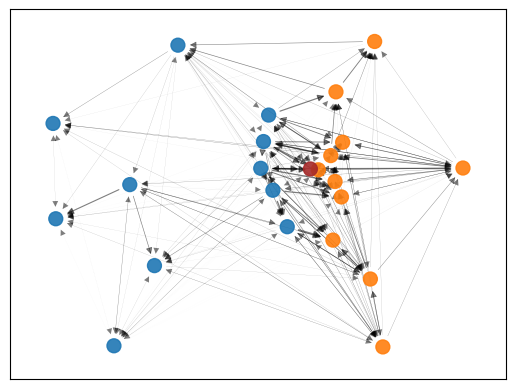

In [16]:
def draw_graph(G, ax=None):
    '''Function to plot teams as graphs, with ball.'''
    colors = {-1: "tab:blue", 1:'tab:orange', 0:'brown'}
    node_colors = []
    pos_dict = {}
    for node, attr in G.nodes(data=True):
        team_def = attr["team_redeffinition"]
        node_colors.append(colors[team_def])
        pos_dict[node] = np.array([attr["pos_x"],attr["pos_y"]])
    edges = G.edges(data=True)
    weights = np.array([v[-1]['weight'] for v in edges])
    pos = pos_dict

    ec = nx.draw_networkx_edges(G, pos, width=4*weights, alpha=0.5, ax=ax, arrowsize=10)
    nc = nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=100, alpha=0.9, ax=ax)

draw_graph(graphs.iloc[0])

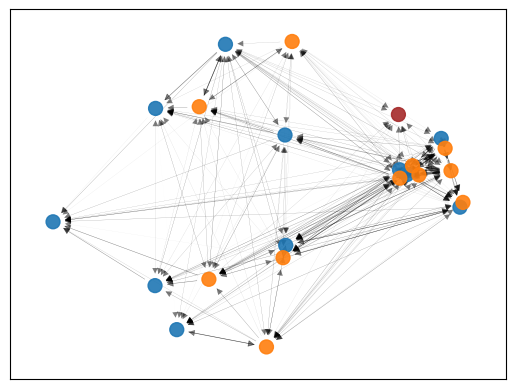

In [17]:
draw_graph(graphs.iloc[108])

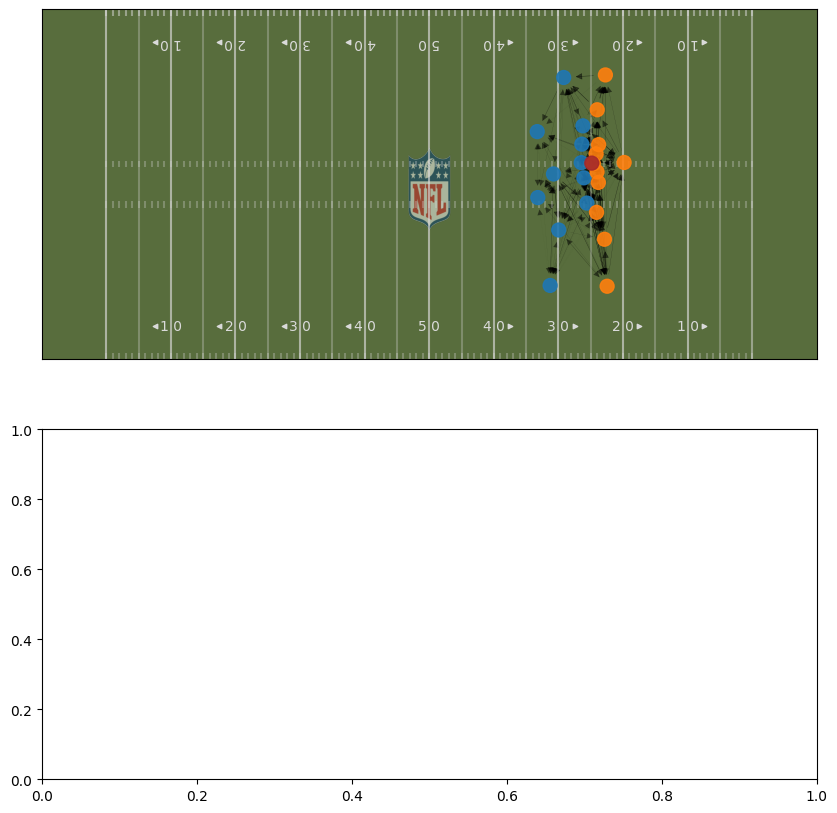

In [18]:
g = graphs.iloc[0]
x_min, x_max = min(nx.get_node_attributes(g, 'pos_x').values()), max(nx.get_node_attributes(g, 'pos_x').values())
y_min, y_max = min(nx.get_node_attributes(g, 'pos_y').values()), max(nx.get_node_attributes(g, 'pos_y').values())
padding = 5
f, ax = plot_field(2, figsize=(10,10))
#ax[0].set_ylim(y_min - padding, y_max + padding)
#ax[0].set_xlim(x_min - padding, x_max + padding)

draw_graph(graphs.iloc[0], ax=ax[0])

In [19]:
def get_all_information(test_df):
    features, graphs, graphs_noline, graphs_bs, graphs_ls = compute_features(test_df)
    graphs.name='graphs'
    predictions = model.predict_proba(features)[:, 1]
    information = test_df[test_df.club=='football'].merge(features, on=['gameId', 'playId', 'frameId'], how='right')
    information['model_pred'] = predictions
    information = information.merge(graphs.reset_index(), on=['gameId', 'playId', 'frameId'], how='left')
    information['time_component'] = pd.to_datetime(information.time, format='ISO8601')
    time_component = (
        information.set_index(['gameId','playId', 'frameId']).time_component - 
        information.groupby(['gameId', 'playId']).time_component.min()
    ).dt.total_seconds().reset_index()
    information = information.drop(['time_component'], axis=1).merge(time_component.reset_index(), on=['gameId', 'playId', 'frameId'], how='left')
    return information

In [20]:
information = get_all_information(test_df)

In [21]:
# samples = tracking_df[tracking_df.club=='football'].sample(
#     20, random_state=42
# ).groupby(['gameId', 'playId']).event.count().index.to_list()

In [22]:
# for s in samples:
#     try: 
#         name = f'{s[0]}-{s[1]}'
#         test_df = tracking_df[(tracking_df.gameId==s[0]) & (tracking_df.playId==s[1])]
#         information = get_all_information(test_df)
#         save_figs(information, filename=name, save=True, stop_counter=None)
#         save_gif(name)
#     except: 
#         pass

In [23]:
n_samples = 30
idx = tracking_df.groupby(['gameId', 'playId',]).frameId.count().sample(n_samples, random_state=42).index
smaller_tracking_df = tracking_df.set_index(['gameId', 'playId', ]).loc[idx].reset_index()

In [24]:
whole_information = get_all_information(smaller_tracking_df)

In [25]:
def save_fig_and_gif(information, filename='test4', save=True, stop_counter=None):
    save_figs(information, filename=filename, save=save, stop_counter=stop_counter)
    save_gif(filename)

In [ ]:
whole_information.groupby(['gameId','playId']).apply(
    lambda x: save_fig_and_gif(
        x, 
        filename=f'{x.gameId.unique()[0]}_{x.playId.unique()[0]}',
        save=True, 
        stop_counter=None
    )
)

In [87]:
whole_information.groupby(['gameId','playId']).apply(get_auc)

gameId      playId
2022110300  883       0.641161
            1409      0.154008
            2185      1.264453
            2353      0.178368
2022110600  326       0.919625
2022110601  56        0.693821
            2336      0.150085
            2595      0.054069
2022110602  177       0.909932
            722       0.938952
            1114      0.065150
2022110604  3026      0.228678
2022110605  56        0.115892
            1863      0.885559
2022110606  3368      0.248710
2022110607  354       0.243037
            1037      1.413281
            1855      0.008980
            2309      1.371171
            3019      0.894406
            3596      0.514571
2022110608  1382      0.280592
            2793      0.333861
            3983      0.046230
            4150      1.888690
2022110609  1254      0.819683
2022110610  2560      0.323586
2022110700  2240      0.037419
            2843      1.078931
            3658      0.121167
dtype: float64

In [86]:
from sklearn.metrics import auc
def get_auc(df):
    return auc(df.time_component, df.model_pred)
def get_play_duration(df):
    return df.time_component.max() - df.time_component.min()
    